In [5]:
import pandas as pd
from biogeme import models
import biogeme.database as db
import biogeme.biogeme as bio
import biogeme.biogeme_logging as blog
import biogeme.distributions as dist
from biogeme.expressions import Variable
from biogeme.expressions import Beta, bioDraws, log, MonteCarlo, exp, RandomVariable, Integrate
import numpy as np
from biogeme.database import Database
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from biogeme.expressions import Beta, bioDraws
from biogeme.database import Database

In [6]:
df = pd.read_csv('train.csv')
database = db.Database('train', df)

In [7]:
globals().update(database.variables)
#print(df.info())
ASC_constant = Beta('constant', 0, None, None, 0)
b_work = Beta('b_work', 0, None, None, 0)
b_personal = Beta('b_personal', 0, None, None, 0)
b_peak = Beta('b_peak', 0, None, None, 0)
b_peak2 = Beta('b_peak2', 0, None, None, 0)
b_time = Beta('b_time', 0, None, None, 0)
b_age  = Beta('b_age', 0, None, None, 0)
b_transfer = Beta('b_transfer', 0, None, None, 0)
b_btw1370s = Beta('b_btw1370s', 0, None, None, 0)
b_btw1360s = Beta ('b_btw1360s', 0, None, None, 0)
b_sit  = Beta('b_sit', 0, None, None, 0)
b_home = Beta('b_home', 0, None, None, 0)
b_line2s = Beta('b_line2s', 0, None, None, 0)
b_fullemploy = Beta('fullemploy', 0, None, None, 0)

In [8]:
ASC_b_time = Beta('ASC_b_time', 0, None, None, 1)
ASC_b_personal = Beta('ASC_b_personal', 0, None, None, 1)
ASC_b_home = Beta('ASC_b_home', 0, None, None, 1)
ASC_b_sit = Beta('ASC_b_sit', 0, None, None, 0)
sigma_s = Beta('sigma_s', 1, None, None, 1)
sigma_p = Beta('sigma_p', 1, None, None, 1)
sigma_h = Beta('sigma_h', 1, None, None, 1)
sigma_bs = Beta('sigma_bs', 1, None, None, 1)

b_time_RND =     ASC_b_time + \
                b_transfer*transfer+\
                b_peak*peak+\
                b_age*age+\
                sigma_s * bioDraws('B_TIME_RND_t', 'NORMAL')

b_personal_RND =  ASC_b_personal+\
                  b_peak2*peak+\
                sigma_p * bioDraws('B_TIME_RND_p', 'NORMAL')

b_home_RND =  ASC_b_home+\
                  b_line2s*line2+\
                sigma_p * bioDraws('B_TIME_RND_h', 'NORMAL')

b_sit_RND =  ASC_b_sit+\
            b_btw1360s*btw1360s+\
            b_btw1370s*btw1370s+\
            sigma_bs * bioDraws('B_TIME_RND_s', 'NORMAL')


In [9]:
V1 = ASC_constant + \
     b_time_RND * totall_duration_journey_group + \
     b_personal_RND * personaltrip + \
     b_home_RND*hometrip+\
     b_sit_RND*siting+\
     b_work*worktrip



V2 = 0

V = {1: V1, 0: V2}

prob = exp(models.loglogit(V, None, adv))

logprob = log(MonteCarlo(prob))
the_biogeme = bio.BIOGEME(database, logprob, number_of_draws = 2000)
the_biogeme.modelName = 'output.random'
results = the_biogeme.estimate()
print(results.short_summary())
pandas_results = results.get_estimated_parameters()
print(pandas_results)

File biogeme.toml has been created


Results for model output.random
Nbr of parameters:		10
Sample size:			342
Excluded data:			0
Final log likelihood:		-212.7068
Akaike Information Criterion:	445.4136
Bayesian Information Criterion:	483.7617

               Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_b_sit  -1.574384      0.571930    -2.752759      0.005910
b_age      -1.588672      0.670156    -2.370599      0.017759
b_btw1360s  2.824342      1.010489     2.795025      0.005190
b_btw1370s  2.319894      0.788548     2.941983      0.003261
b_line2s    1.661531      0.991295     1.676121      0.093714
b_peak     -0.557558      0.212990    -2.617768      0.008851
b_peak2     2.125779      0.711293     2.988611      0.002802
b_transfer  0.506112      0.236193     2.142792      0.032130
b_work      0.953681      0.425398     2.241852      0.024971
constant   -0.334613      0.397436    -0.841929      0.399827


In [25]:
new_data = pd.read_csv('tatal_for_augmentation(everything).csv')

In [8]:
new_data.drop(columns=['Unnamed: 0'], inplace=True) 

In [17]:
est_params

,Value,Rob. Std err,Rob. t-test,Rob. p-value
ASC_b_sit,-1.559839,0.574897,-2.713252,0.006663
b_age,-1.584610,0.667786,-2.372931,0.017648
b_btw1360s,2.802446,1.010552,2.773182,0.005551
b_btw1370s,2.289192,0.786547,2.910431,0.003609
b_line2s,1.648327,0.984046,1.675051,0.093924
b_peak,-0.557936,0.214007,-2.607098,0.009131
b_peak2,2.129537,0.710481,2.997319,0.002724
b_transfer,0.500697,0.236527,2.116867,0.034271
b_work,0.946487,0.424457,2.229875,0.025756
constant,-0.335839,0.396469,-0.847075,0.396953


In [34]:
import numpy as np
import pandas as pd
from biogeme.expressions import Beta, bioDraws

def predict_new_data(new_data, est_params, n_draws=1000, seed=42):
    """
    Predict choice probabilities for new data using estimated mixed logit parameters
    
    """
    # Set random seed
    np.random.seed(seed)
    
    # Extract parameters
    params = {
        'ASC_constant': est_params.get('constant', 0),
        'b_work': est_params.get('b_work', 0),
        'b_peak': est_params.get('b_peak', 0),
        'b_peak2': est_params.get('b_peak2', 0),
        'b_age': est_params.get('b_age', 0),
        'b_transfer': est_params.get('b_transfer', 0),
        'b_btw1370s': est_params.get('b_btw1370s', 0),
        'b_btw1360s': est_params.get('b_btw1360s', 0),
        'b_line2s': est_params.get('b_line2s', 0),
        'ASC_b_sit': est_params.get('ASC_b_sit', 0),
        'ASC_b_time': est_params.get('ASC_b_time', 0),
        'ASC_b_personal': est_params.get('ASC_b_personal', 0),
        'ASC_b_home': est_params.get('ASC_b_home', 0),
        'sigma_s': est_params.get('sigma_s', 1),
        'sigma_p': est_params.get('sigma_p', 1),
        'sigma_h': est_params.get('sigma_h', 1),
        'sigma_bs': est_params.get('sigma_bs', 1)
    }
    
    # Initialize arrays to store probabilities
    n_obs = len(new_data)
    probs_V1 = np.zeros((n_obs, n_draws))
    
    # Simulate n_draws times
    for draw in range(n_draws):
        # Generate random terms
        eps_s = np.random.normal(0, params['sigma_s'], n_obs)
        eps_p = np.random.normal(0, params['sigma_p'], n_obs)
        eps_h = np.random.normal(0, params['sigma_h'], n_obs)
        eps_bs = np.random.normal(0, params['sigma_bs'], n_obs)
        
        # Calculate utility V1
        V1 = (params['ASC_constant'] + 
              (params['ASC_b_time'] + params['b_transfer'] * new_data['transfer'] + 
               params['b_peak'] * new_data['peak'] + 
               params['b_age'] * new_data['age'] + 
               eps_s) * new_data['total_duration_journey_group'] +
              (params['ASC_b_personal'] + params['b_peak2'] * new_data['peak'] + 
               eps_p) * new_data['personaltrip'] +
              (params['ASC_b_home'] + params['b_line2s'] * new_data['line2s'] + 
               eps_h) * new_data['hometrip'] +
              (params['ASC_b_sit'] + params['b_btw1360s'] * new_data['btw1360s'] + 
               params['b_btw1370s'] * new_data['btw1370s'] + 
               eps_bs) * new_data['siting'] +
              params['b_work'] * new_data['worktrip'])
        
        # V2 is normalized to 0
        V2 = np.zeros(n_obs)
        
        # Calculate probabilities for this draw
        probs_V1[:, draw] = np.exp(V1) / (np.exp(V1) + np.exp(V2))
    
    # Calculate mean probabilities across draws
    mean_probs = pd.DataFrame({
        'V1_prob': np.mean(probs_V1, axis=1),
        'V2_prob': 1 - np.mean(probs_V1, axis=1)
    })
    
    # Add prediction intervals
    mean_probs['V1_prob_lower'] = np.percentile(probs_V1, 2.5, axis=1)
    mean_probs['V1_prob_upper'] = np.percentile(probs_V1, 97.5, axis=1)
    
    return mean_probs

# Example usage:
# predictions = predict_new_data(database2, est_params, n_draws=1000, seed=42)

In [27]:
new_data.columns

Index(['Unnamed: 0', 'ETCARD_ID', 'Origin_Station_ID', 'Time_Boarding',
       'Destination_Station_ID', 'Time_Alighting', 'Line_ID_origin',
       'Line_ID_dist', 'GroupKey', 'transfer', 'male', 'siting', 'hometrip',
       'worktrip', 'personaltrip', 'btw1360s', 'btw1370s', 'age',
       'total_duration_journey', 'total_duration_journey_group', 'line2s',
       'peak'],
      dtype='object')

In [30]:
new_data = pd.read_csv('tatal_for_augmentation(everything).csv')
database2 = db.Database('tatal_for_augmentation(everything).csv', new_data)

In [35]:
# Get your estimated parameters
est_params = results.get_estimated_parameters()

# Make predictions
predictions = predict_new_data(new_data , est_params, n_draws=100, seed=42)

# View results
print(predictions.head())

    V1_prob   V2_prob  V1_prob_lower  V1_prob_upper
0  0.488147  0.511853       0.116456       0.870533
1  0.551235  0.448765       0.067784       0.972998
2  0.486538  0.513462       0.071104       0.940755
3  0.501406  0.498594       0.115227       0.864943
4  0.525482  0.474518       0.065517       0.918381


In [36]:
predictions.to_csv('predictions.csv')

In [10]:
import pandas as pd
import numpy as np
from biogeme.database import Database
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from typing import Dict, Any, Tuple

def plot_roc_curve(y_true: np.ndarray, y_pred_prob: np.ndarray) -> Tuple[plt.Figure, float]:
    """
    Plot ROC curve and calculate AUC
    
    """
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    
    # Create plot
    plt.figure(figsize=(10, 8))
    plt.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
             label='Random classifier')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    
    return plt.gcf(), roc_auc

def evaluate_predictions(predictions: pd.DataFrame, actual_choices: np.ndarray, 
                        threshold: float = 0.5) -> Dict[str, Any]:
    """
    Evaluate model predictions with multiple metrics
        
    Returns:
        Dictionary containing evaluation metrics and visualizations
    """
    # Convert probabilities to binary predictions using threshold
    predicted_choices = (predictions['V1_prob'] > threshold).astype(int)
    
    # Calculate basic metrics
    accuracy = accuracy_score(actual_choices, predicted_choices)
    conf_matrix = confusion_matrix(actual_choices, predicted_choices)
    class_report = classification_report(actual_choices, predicted_choices)
    
    # Calculate ROC curve and AUC
    fig, roc_auc = plot_roc_curve(actual_choices, predictions['V1_prob'])
    
    # Calculate additional statistics
    results = {
        'accuracy': accuracy,
        'confusion_matrix': conf_matrix,
        'classification_report': class_report,
        'average_probability': predictions['V1_prob'].mean(),
        'predicted_shares': predicted_choices.mean(),
        'actual_shares': actual_choices.mean(),
        'roc_curve': fig,
        'roc_auc': roc_auc,
        # Additional metrics
        'predictions': predictions,
        'threshold_used': threshold
    }
    
    return results
def calculate_random_parameters(data: pd.DataFrame, betas: Dict[str, float], 
                              draws: Dict[str, np.ndarray]) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Calculate random parameters for the utility function
        
    Returns:
        Tuple of random parameters (b_time_RND, b_personal_RND, b_home_RND, b_sit_RND)
    """
    # Time random parameter
    b_time_RND = ( 
                  betas['b_transfer'] * data['transfer'] +
                  betas['b_peak'] * data['peak'] +
                  betas['b_age'] * data['age'] +
                  1 * draws['B_TIME_RND_t'])
    
    # Personal random parameter
    b_personal_RND = (
                      betas['b_peak2'] * data['peak'] +
                      1 * draws['B_TIME_RND_p'])
    
    # Home random parameter
    b_home_RND = (
                  betas['b_line2s'] * data['line2'] +
                  1 * draws['B_TIME_RND_h'])
    
    # Sit random parameter
    b_sit_RND = (betas['ASC_b_sit'] +
                 betas['b_btw1360s'] * data['btw1360s'] +
                 betas['b_btw1370s'] * data['btw1370s'] +
                 1* draws['B_TIME_RND_s'])
    
    return b_time_RND, b_personal_RND, b_home_RND, b_sit_RND

def calculate_utility(data: pd.DataFrame, betas: Dict[str, float], 
                     random_params: Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray], 
                     alternative: int) -> np.ndarray:
    """
    Calculate utility for a specific alternative
        
    Returns:
        Utility values
    """
    if alternative == 1:
        b_time_RND, b_personal_RND, b_home_RND, b_sit_RND = random_params
        
        utility = (betas['constant'] +
                  b_time_RND * data['totall_duration_journey_group'] +
                  b_personal_RND * data['personaltrip'] +
                  b_home_RND * data['hometrip'] +
                  b_sit_RND * data['siting'] +
                  betas['b_work'] * data['worktrip'])
    else:
        utility = 0
    
    return utility

def predict_new_data(model, test_database: Database, n_draws: int = 2000, 
                    batch_size: int = 50, seed: int = 42) -> pd.DataFrame:
    """
    Make predictions on new data using the estimated model
        
    Returns:
        DataFrame with prediction probabilities
    """
    np.random.seed(seed)
    
    # Extract parameters
    betas = model.getBetaValues()
    
    # Initialize results storage
    all_probabilities = []
    
    # Process in batches
    for start_idx in range(0, len(test_database.data), batch_size):
        end_idx = min(start_idx + batch_size, len(test_database.data))
        batch_data = test_database.data.iloc[start_idx:end_idx]
        
        # Generate random draws for each random parameter
        draws = {
            'B_TIME_RND_t': np.random.normal(size=(len(batch_data), n_draws)),
            'B_TIME_RND_p': np.random.normal(size=(len(batch_data), n_draws)),
            'B_TIME_RND_h': np.random.normal(size=(len(batch_data), n_draws)),
            'B_TIME_RND_s': np.random.normal(size=(len(batch_data), n_draws))
        }
        
        batch_probs = []
        
        # Monte Carlo simulation
        for i in range(n_draws):
            draw_set = {k: v[:, i] for k, v in draws.items()}
            
            # Calculate random parameters
            random_params = calculate_random_parameters(batch_data, betas, draw_set)
            
            # Calculate utilities
            V1 = calculate_utility(batch_data, betas, random_params, 1)
            V2 = calculate_utility(batch_data, betas, random_params, 0)
            
            # Calculate probabilities
            exp_v1 = np.exp(V1)
            exp_v2 = np.exp(V2)
            probs = exp_v1 / (exp_v1 + exp_v2)
            batch_probs.append(probs)
        
        # Average probabilities across draws
        avg_probs = np.mean(batch_probs, axis=0)
        all_probabilities.extend(avg_probs)
    
    # Create results DataFrame
    predictions = pd.DataFrame({
        'V1_prob': all_probabilities,
        'V2_prob': [1 - p for p in all_probabilities]
    })
    
    return predictions

def test_model(model, test_df: pd.DataFrame, actual_choice_column: str = 'adv') -> Tuple[pd.DataFrame, Dict[str, Any]]:
    """
    Complete testing pipeline
    
    Returns:
        Predictions and evaluation results
    """
    # Create Biogeme database
    test_database = Database('test', test_df)
    
    # Make predictions
    predictions = predict_new_data(model, test_database, n_draws=2000)
    
    # Get actual choices
    actual_choices = test_df[actual_choice_column].values
    
    # Evaluate predictions
    evaluation_results = evaluate_predictions(predictions, actual_choices)
    
    return predictions, evaluation_results

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12732\2272373483.py:165: DeprecationWarning: getBetaValues is deprecated; use get_beta_values instead.
  betas = model.getBetaValues()


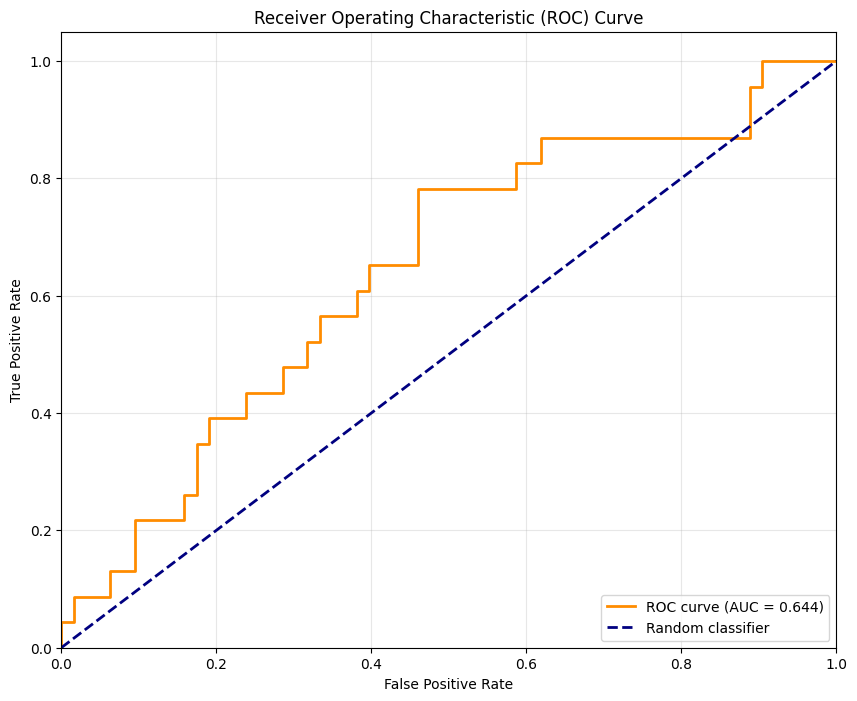

In [11]:

test_df = pd.read_excel('mlogit_test.xlsx')

# Make sure test_df has all required columns:
required_columns = [
    'transfer', 'peak', 'age', 'line2', 'btw1360s', 'btw1370s',
    'totall_duration_journey_group', 'personaltrip', 'hometrip',
    'siting', 'worktrip', 'adv'
]

# Test the model
predictions, evaluation = test_model(results, test_df)

In [12]:
print(f"Accuracy: {evaluation['accuracy']:.3f}")

Accuracy: 0.686


In [13]:
print(evaluation['classification_report'])

              precision    recall  f1-score   support

           0       0.76      0.84      0.80        63
           1       0.38      0.26      0.31        23

    accuracy                           0.69        86
   macro avg       0.57      0.55      0.55        86
weighted avg       0.65      0.69      0.67        86

